<a href="https://colab.research.google.com/github/CRO-RNLD/Examen-Practico-2-Mineria-Datos/blob/main/Examen-2-Mineria%20de%20Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LECTURA DE DATOS


In [1]:
# Importación de librerías esenciales para manipulación de datos y gráficos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración por defecto para los gráficos
sns.set_theme(style="whitegrid")

In [2]:
# Carga de ambos archivos CSV desde el directorio
df_academico = pd.read_csv('dataset_academico.csv')
df_psicosocial = pd.read_csv('dataset_psicosocial.csv')

# Verificación de las dimensiones
print(f"Dimensiones del dataset académico: {df_academico.shape}")
print(f"Dimensiones del dataset psicosocial: {df_psicosocial.shape}")

Dimensiones del dataset académico: (3000, 17)
Dimensiones del dataset psicosocial: (3000, 20)


In [3]:
# Combinamos ambos datasets usando la columna común 'id_estudiante'
# Usamos un 'inner' join para asegurarnos de trabajar con estudiantes que tengan historial completo
df_estudiantes = pd.merge(df_academico, df_psicosocial, on='id_estudiante', how='inner')

# Guardamos una copia del dataset integrado
df_estudiantes.to_csv('dataset_inicial_integrado.csv', index=False)

print(f"Dimensiones del dataset unificado: {df_estudiantes.shape}")

Dimensiones del dataset unificado: (3000, 36)


In [4]:
# Inspección de las primeras filas del conjunto de datos unificado
df_estudiantes.head()

,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,...,nivel_autoestima,nivel_ansiedad,nivel_motivacion_escolar,apoyo_familiar_percibido,eventos_estresantes_recientes,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
0,3169,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,...,5.0,1,4,4,0,Regular,7.2,0,1,1
1,1163,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,...,3.0,2,5,3,0,Regular,7.9,0,0,0
2,2517,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,...,3.0,2,5,4,0,Regular,6.7,0,0,0
3,2318,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,...,5.0,2,3,3,0,Buena,5.2,0,1,0
4,1686,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,...,4.0,2,3,4,0,Buena,6.8,0,1,0


# ANALISIS EXPLORATORIO DE DATOS (EDA)

In [5]:
# PROCESO: Verificamos los tipos de datos asignados por Pandas para asegurarnos
# de que no existan números leídos como texto (object) ni errores estructurales.
print("=== INFORMACIÓN GENERAL DEL DATASET UNIFICADO ===")
df_estudiantes.info()

=== INFORMACIÓN GENERAL DEL DATASET UNIFICADO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id_estudiante                            3000 non-null   int64  
 1   edad                                     3000 non-null   float64
 2   grado                                    3000 non-null   int64  
 3   promedio_matematica                      3000 non-null   float64
 4   promedio_comunicacion                    3000 non-null   float64
 5   promedio_ciencias                        2910 non-null   float64
 6   promedio_general                         3000 non-null   float64
 7   num_cursos_desaprobados                  3000 non-null   int64  
 8   porcentaje_asistencia                    2940 non-null   float64
 9   num_tardanzas                            3000 non-null   int64  
 10

In [6]:
# PROCESO: Calculamos estadísticas de tendencia central (media, mediana) y dispersión (desviación, rangos)
# RESULTADO ESPERADO: Identificar posibles valores ilógicos (ej. promedios mayores a 20 o porcentajes mayores a 100).
df_estudiantes.describe().T

,count,mean,std,min,25%,50%,75%,max
id_estudiante,3000.0,2500.500000,866.169729,1001.00,1750.7500,2500.500,3250.2500,4000.00
edad,3000.0,14.462667,1.550723,6.00,13.0000,14.000,16.0000,30.00
grado,3000.0,2.958333,1.412774,1.00,2.0000,3.000,4.0000,5.00
promedio_matematica,3000.0,12.209660,4.058927,0.00,9.2375,12.240,15.2125,20.00
promedio_comunicacion,3000.0,12.295623,4.087180,0.00,9.4000,12.355,15.4000,20.00
promedio_ciencias,2910.0,12.389969,4.126823,0.00,9.4800,12.490,15.5200,20.00
promedio_general,3000.0,12.312043,3.605354,2.14,9.6175,12.395,15.1600,20.00
num_cursos_desaprobados,3000.0,1.882000,1.768932,0.00,0.0000,2.000,3.0000,9.00
porcentaje_asistencia,2940.0,78.370748,12.408769,31.60,69.9000,78.700,87.7250,112.70
num_tardanzas,3000.0,4.870000,3.554431,0.00,2.0000,4.000,7.0000,57.00


In [7]:
# PROCESO: Inspeccionamos las variables de tipo texto/objeto para conocer sus clases y categorías más frecuentes.
# RESULTADO ESPERADO: Ver la diversidad de respuestas en variables como 'tendencia_notas', 'estructura_familiar', etc.
df_estudiantes.describe(include='object').T

,count,unique,top,freq
tendencia_notas,2880,3,Mejorando,1018
participacion_clase,3000,3,Media,1142
target,3000,3,Necesita_reforzamiento,1196
genero,3000,3,Masculino,1436
estructura_familiar,3000,4,Ambos padres,1611
nivel_socioeconomico,2880,4,Medio,1140
nivel_educativo_padres,2850,4,Secundaria,1245
relacion_con_companeros,2910,3,Regular,1254


In [8]:
# PROCESO: Contamos exactamente cuántos valores nulos (NaN) existen por cada columna.
# JUSTIFICACIÓN: Los algoritmos como SVM o Random Forest en Scikit-Learn no toleran valores nulos.
nulos = df_estudiantes.isnull().sum()
porcentaje_nulos = (nulos / len(df_estudiantes)) * 100
tabla_nulos = pd.DataFrame({'Total Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos})

# Mostramos solo las columnas que tengan al menos 1 valor nulo
tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

,Total Nulos,Porcentaje (%)
horas_trabajo_semanal,2210,73.666667
horas_estudio_semanal,180,6.000000
nivel_educativo_padres,150,5.000000
entrega_tareas,150,5.000000
nivel_socioeconomico,120,4.000000
tendencia_notas,120,4.000000
promedio_ciencias,90,3.000000
relacion_con_companeros,90,3.000000
nivel_autoestima,90,3.000000
porcentaje_asistencia,60,2.000000


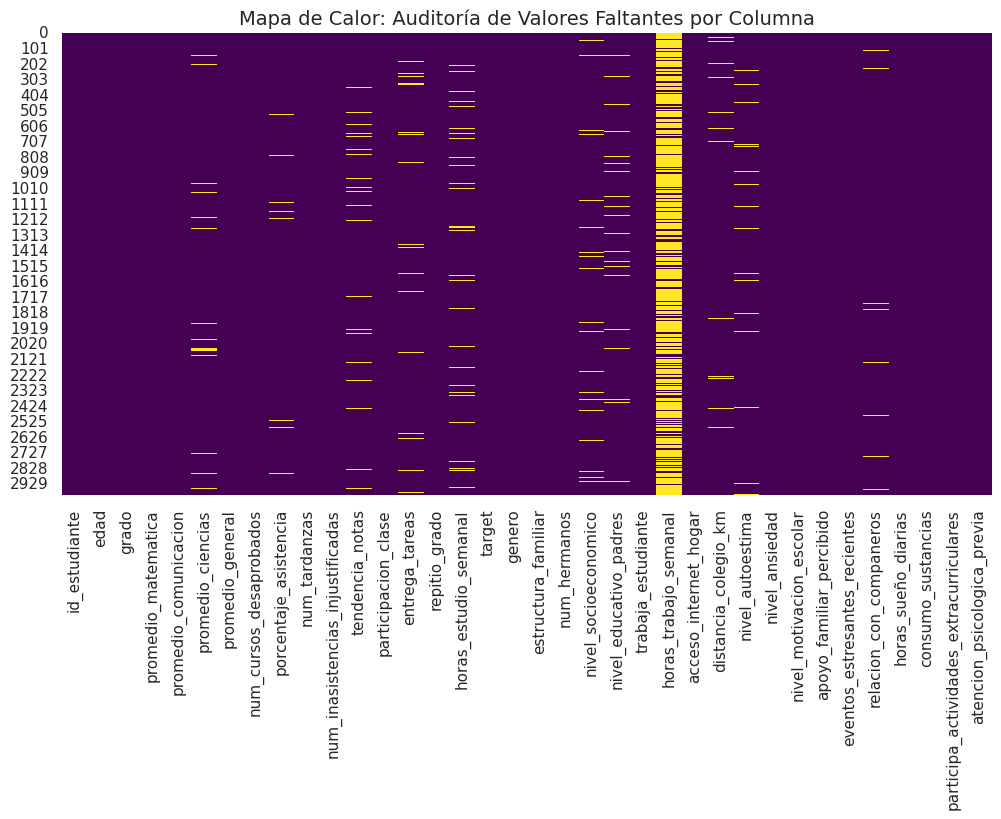

In [9]:
# PROCESO: Representación gráfica de la ubicación de los valores nulos en el dataset.
# INTERPRETACIÓN: Nos permite ver si los nulos forman patrones aleatorios o bloques concentrados en ciertas filas.
plt.figure(figsize=(12, 6))
sns.heatmap(df_estudiantes.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de Calor: Auditoría de Valores Faltantes por Columna", fontsize=14)
plt.show()

In [10]:
# PROCESO: Comprobamos si durante el merge o en la recolección se duplicaron filas idénticas, Porque los duplicados generan sesgos (sobreajuste) en el modelo de Machine Learning.
duplicados = df_estudiantes.duplicated().sum()
print(f"Total de registros completamente duplicados en el dataset: {duplicados}")

Total de registros completamente duplicados en el dataset: 0


=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===


,Conteo,Porcentaje (%)
target,,
Necesita_reforzamiento,1196,39.866667
Continua_estudiando,1195,39.833333
Suspendido,609,20.300000


/tmp/ipykernel_9018/100355060.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_estudiantes, palette='Set2', order=conteo_clases.index)


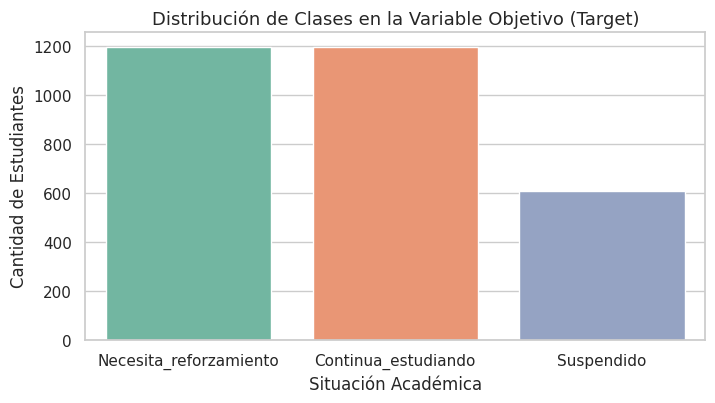

In [11]:
# PROCESO: Evaluamos el balance de clases en la variable objetivo ('target').
# INTERPRETACIÓN CRÍTICA: Si una clase (ej. 'Suspendido') tiene muy pocos registros comparada con otra,
# el modelo podría sufrir un sesgo mayoritario. Revisaremos sus conteos exactos y proporciones.
conteo_clases = df_estudiantes['target'].value_counts()
proporciones = df_estudiantes['target'].value_counts(normalize=True) * 100

tabla_target = pd.DataFrame({'Conteo': conteo_clases, 'Porcentaje (%)': proporciones})
print("=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===")
display(tabla_target)

# Gráfico de barras de la variable objetivo
plt.figure(figsize=(8, 4))
sns.countplot(x='target', data=df_estudiantes, palette='Set2', order=conteo_clases.index)
plt.title("Distribución de Clases en la Variable Objetivo (Target)", fontsize=13)
plt.xlabel("Situación Académica")
plt.ylabel("Cantidad de Estudiantes")
plt.show()

<Figure size 1600x1200 with 0 Axes>

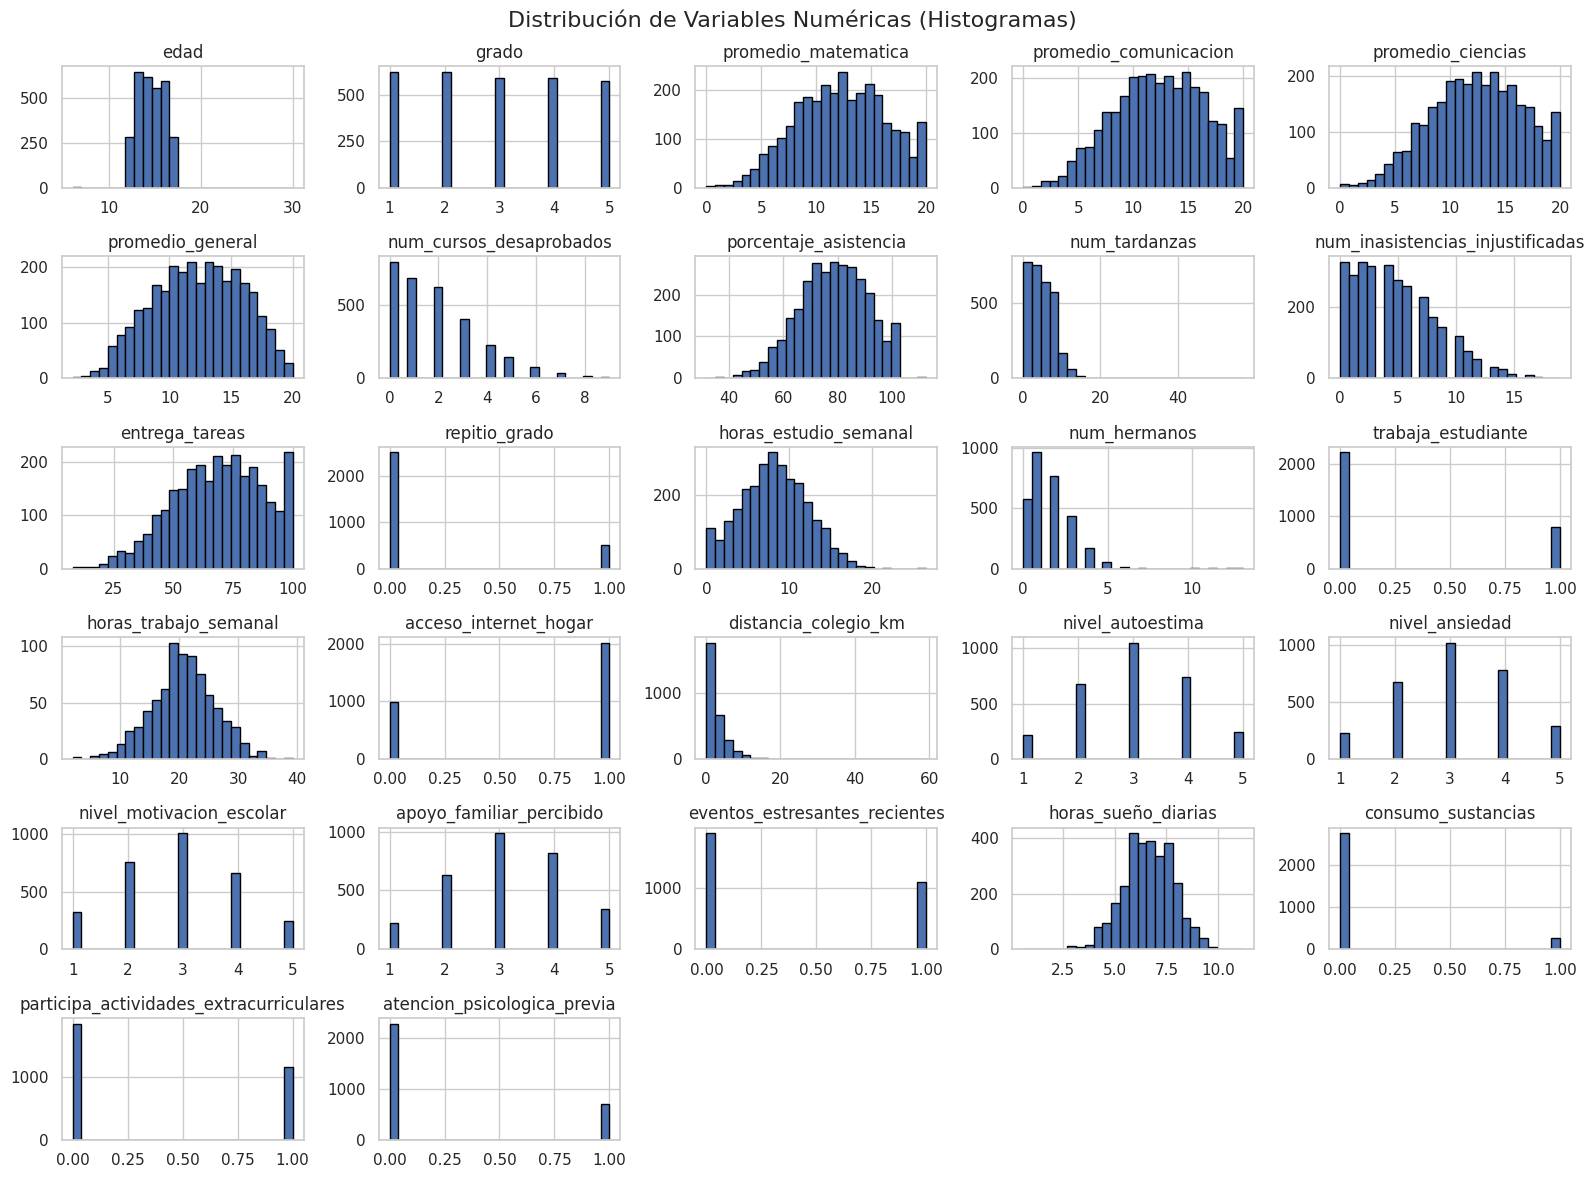

In [12]:
# PROCESO: Visualizamos las distribuciones numéricas para ver sesgos (campana de Gauss vs. distribuciones sesgadas).
# JUSTIFICACIÓN: Nos ayuda a entender el comportamiento general de las notas, asistencias y escalas psicológicas.
numericas = df_estudiantes.select_dtypes(include=np.number)

# Excluimos id_estudiante porque es solo un código numérico
cols_num_graficar = numericas.drop(columns=['id_estudiante'], errors='ignore')

plt.figure(figsize=(16, 12))
cols_num_graficar.hist(bins=25, figsize=(16, 12), edgecolor='black', color='#4C72B0')
plt.suptitle("Distribución de Variables Numéricas (Histogramas)", fontsize=16)
plt.tight_layout()
plt.show()

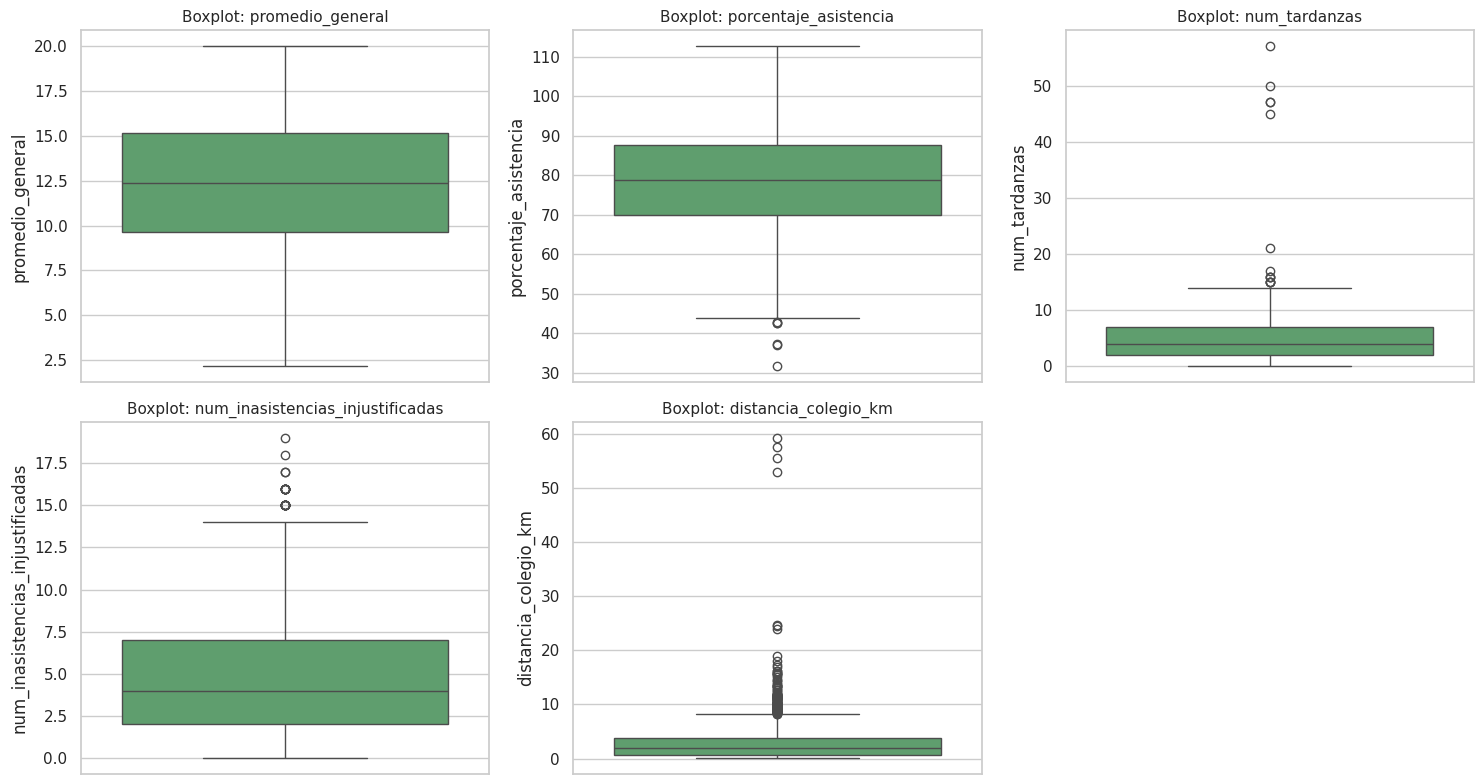

In [13]:
# PROCESO: Generamos diagramas de caja (Boxplots) para identificar valores atípicos (puntos fuera de los bigotes).
# INTERPRETACIÓN: Analizamos si hay estudiantes con notas extremas, tardanzas anormales o distancias muy altas.
columnas_outliers = [
    'promedio_general', 'porcentaje_asistencia', 'num_tardanzas',
    'num_inasistencias_injustificadas', 'distancia_colegio_km'
]

plt.figure(figsize=(15, 8))
for i, col in enumerate(columnas_outliers, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_estudiantes[col], color='#55A868')
    plt.title(f"Boxplot: {col}", fontsize=11)
plt.tight_layout()
plt.show()

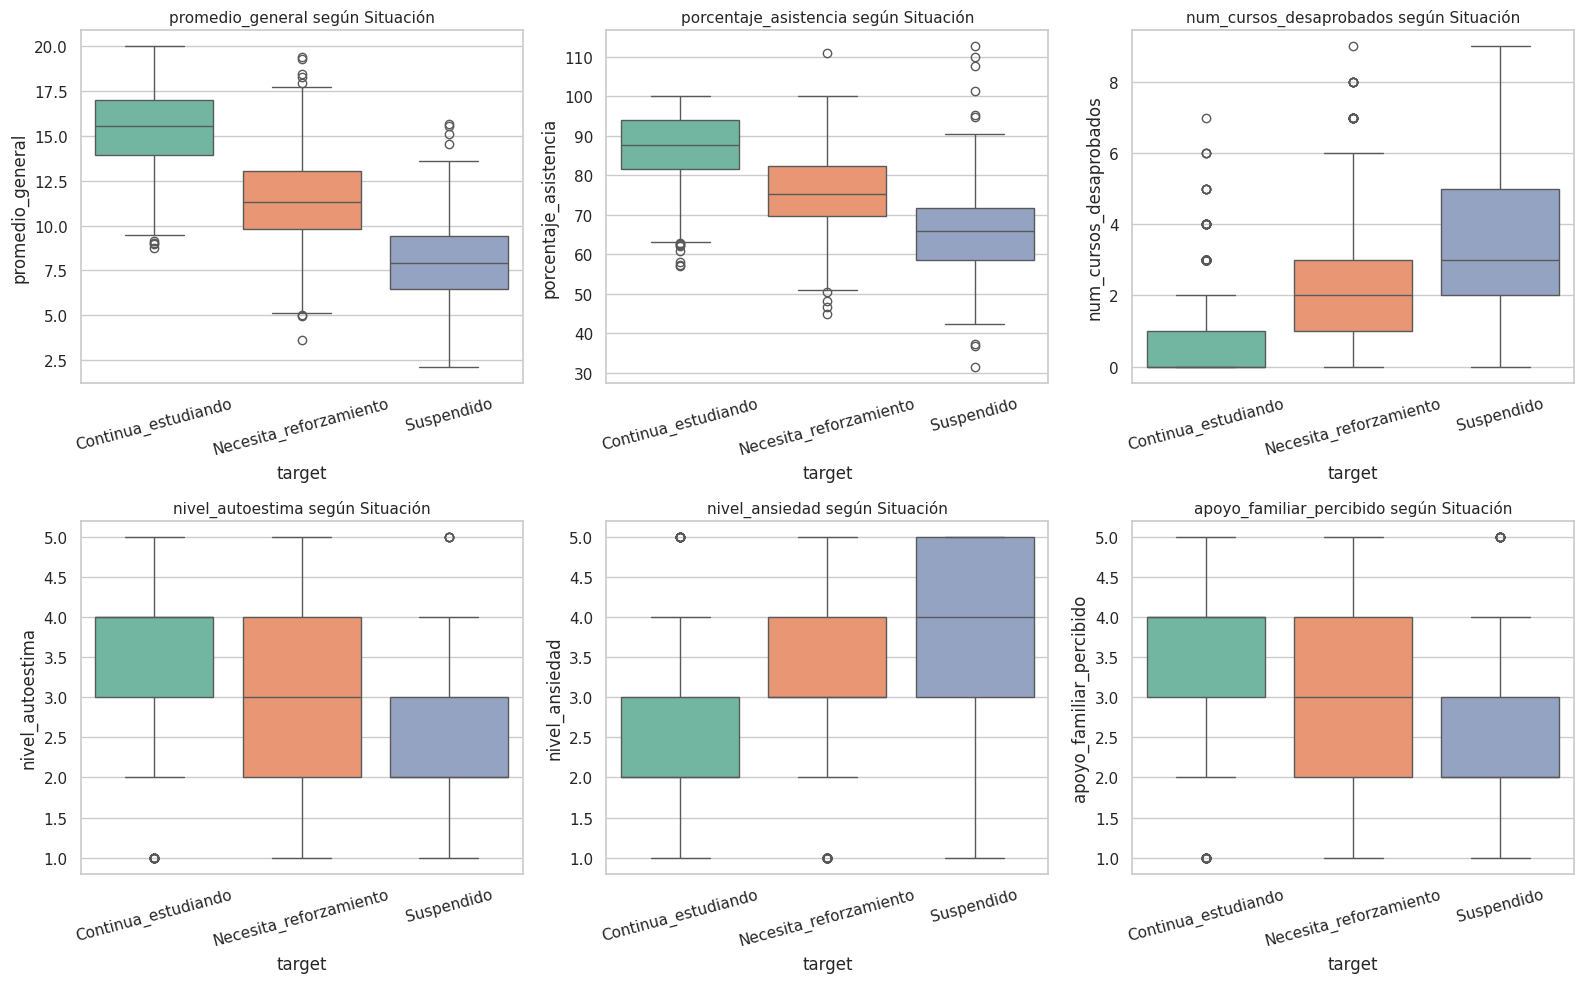

In [14]:
# PROCESO: Comparamos el comportamiento numérico de cada grupo según su situación académica ('target').
# HALLAZGO ESPERADO: Ver claramente si los 'Suspendidos' tienen peores promedios, menor asistencia y mayor ansiedad.
variables_clave_vs_target = [
    'promedio_general', 'porcentaje_asistencia', 'num_cursos_desaprobados',
    'nivel_autoestima', 'nivel_ansiedad', 'apoyo_familiar_percibido'
]

plt.figure(figsize=(16, 10))
for i, col in enumerate(variables_clave_vs_target, 1):
    plt.subplot(2, 3, i)
    # Agregamos hue=target para evitar el warning de Seaborn
    sns.boxplot(x='target', y=col, hue='target', data=df_estudiantes, palette='Set2', legend=False)
    plt.title(f"{col} según Situación", fontsize=11)
    plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

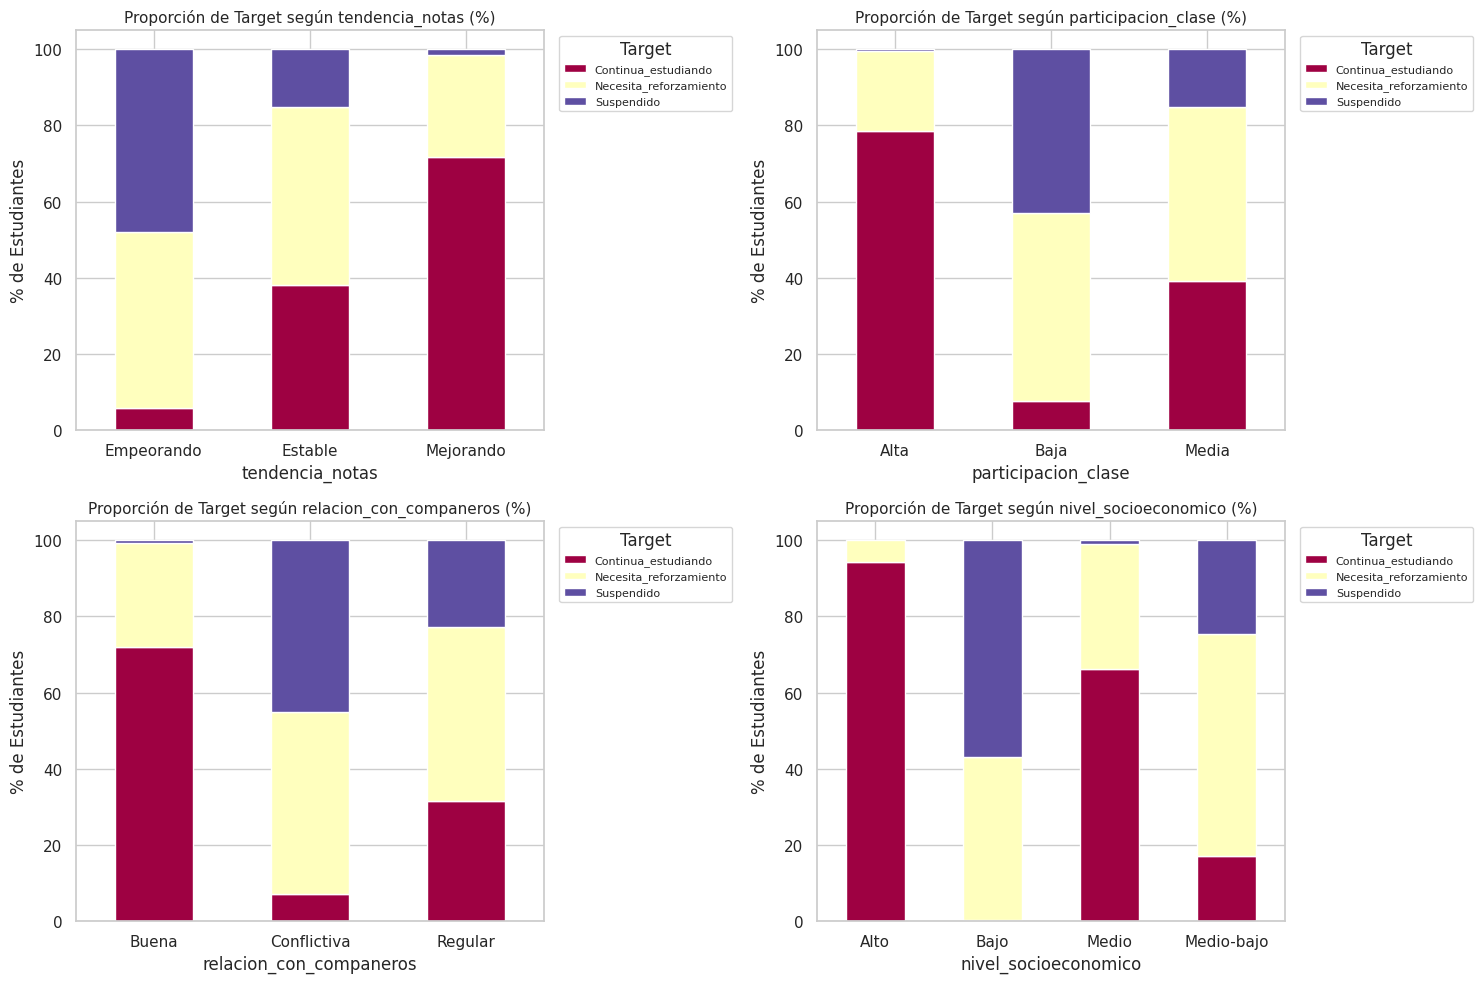

In [15]:
# PROCESO: Evaluamos cómo influyen variables sociales y de comportamiento en la deserción escolar.
# JUSTIFICACIÓN: Las proporciones apiladas permiten ver si tener 'conflictos con compañeros' o 'empeorar notas'
# dispara el porcentaje de suspensión.
categoricas_clave = ['tendencia_notas', 'participacion_clase', 'relacion_con_companeros', 'nivel_socioeconomico']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categoricas_clave, 1):
    plt.subplot(2, 2, i)
    tabla = pd.crosstab(df_estudiantes[col], df_estudiantes['target'], normalize='index') * 100
    tabla.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Spectral')
    plt.title(f"Proporción de Target según {col} (%)", fontsize=11)
    plt.ylabel("% de Estudiantes")
    plt.xticks(rotation=0)
    plt.legend(title='Target', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

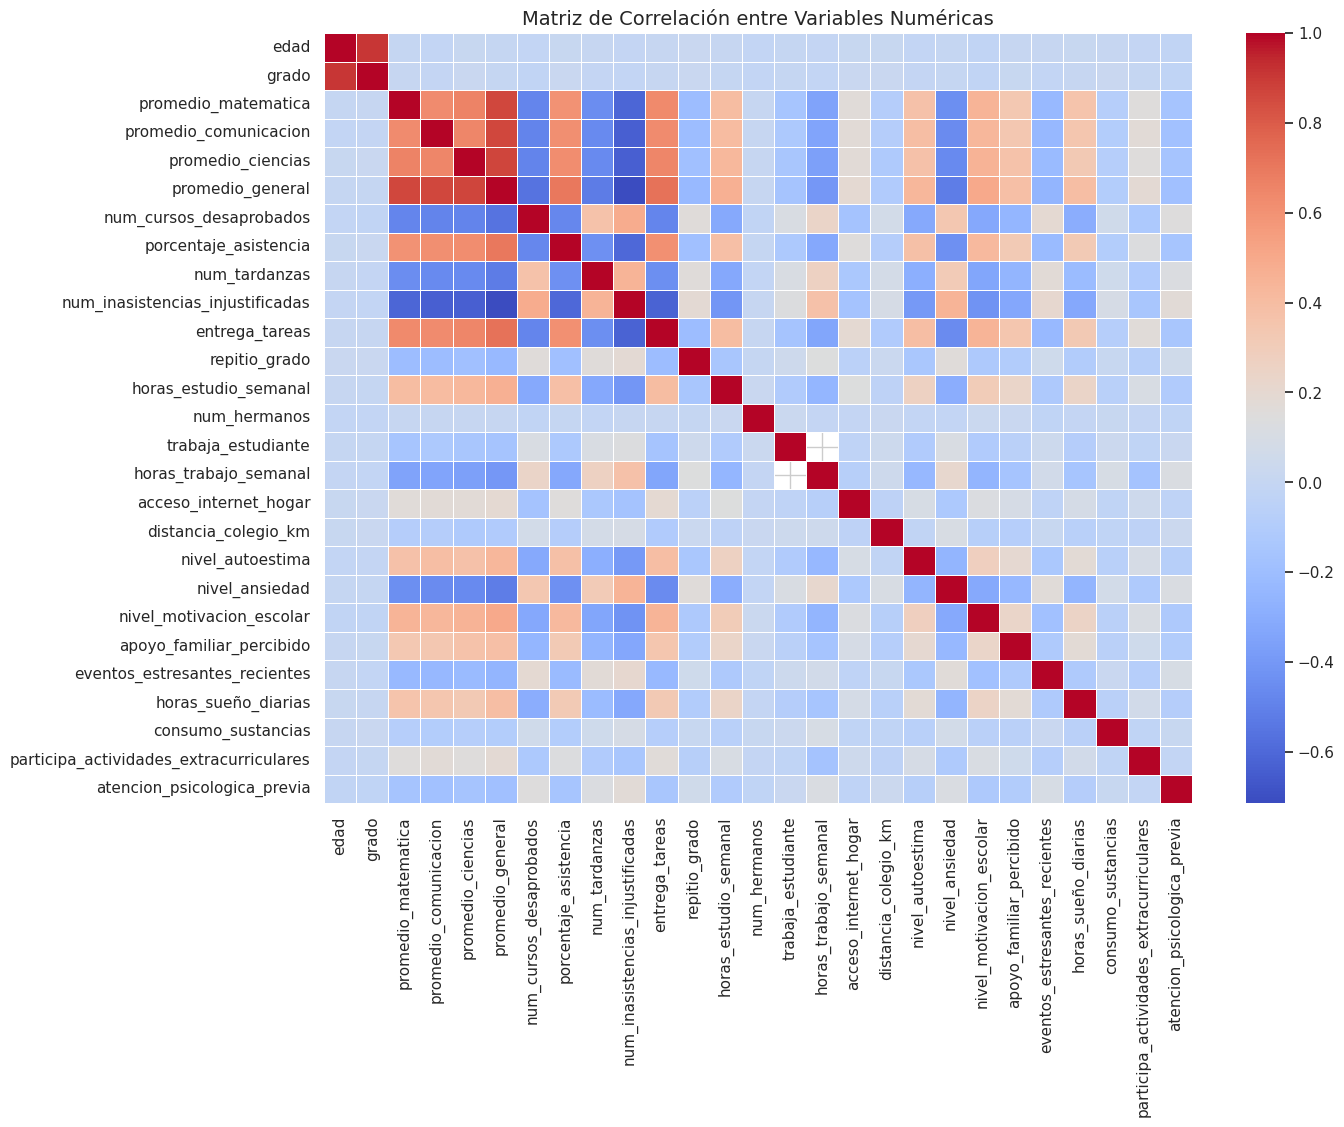

In [16]:
# PROCESO: Evaluamos la colinealidad lineal entre variables numéricas mediante el Coeficiente de Pearson.
# INTERPRETACIÓN: Nos permite identificar si promedios de cursos específicos están extremadamente correlacionados
# con el promedio general (lo cual es normal al ser una media ponderada).
plt.figure(figsize=(14, 10))
corr_matrix = cols_num_graficar.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas", fontsize=14)
plt.show()

# PRE-PROCESAMIENTO DE DATOS

In [17]:
# PROCESO: Creamos una copia del dataset para preprocesar sin alterar el original.
# Borramos 'id_estudiante' porque es un código identificador sin valor predictivo.
df_prep = df_estudiantes.copy()

if 'id_estudiante' in df_prep.columns:
    df_prep.drop(columns=['id_estudiante'], inplace=True)
    print("-> Columna 'id_estudiante' eliminada correctamente.")

print(f"Dimensiones actuales para preprocesamiento: {df_prep.shape}")

-> Columna 'id_estudiante' eliminada correctamente.
Dimensiones actuales para preprocesamiento: (3000, 35)


In [18]:
# PROCESO E INTERPRETACIÓN DE NEGOCIO: La columna 'horas_trabajo_semanal' tenía un 73.67% de nulos.
# Al cruzar con la lógica del dataset, esos nulos corresponden a estudiantes que NO trabajan ('trabaja_estudiante' == 'No').
# Por lo tanto, imputamos esos nulos específicamente con el valor lógico de 0 horas en lugar de usar medias o modas.
df_prep['horas_trabajo_semanal'] = df_prep['horas_trabajo_semanal'].fillna(0)

print(f"Nulos restantes en 'horas_trabajo_semanal': {df_prep['horas_trabajo_semanal'].isnull().sum()}")

Nulos restantes en 'horas_trabajo_semanal': 0


In [19]:
# PROCESO: Para el pequeño porcentaje de nulos restantes (entre 2% y 6%), aplicamos imputación estadística:
# - Mediana/Media para variables continuas (ej. horas de estudio, promedio ciencias, asistencia, distancia).
# - Moda (valor más frecuente) para variables categóricas u ordinales (ej. nivel educativo padres, autoestima).
from sklearn.impute import SimpleImputer

# Separamos columnas numéricas y categóricas que aún tengan nulos
cols_con_nulos = df_prep.columns[df_prep.isnull().any()].tolist()
num_nulos = df_prep[cols_con_nulos].select_dtypes(include=np.number).columns
cat_nulos = df_prep[cols_con_nulos].select_dtypes(exclude=np.number).columns

# Imputamos numéricas con la mediana (es robusta ante outliers)
if len(num_nulos) > 0:
    imp_num = SimpleImputer(strategy='median')
    df_prep[num_nulos] = imp_num.fit_transform(df_prep[num_nulos])
    print(f"-> Columnas numéricas imputadas con mediana: {list(num_nulos)}")

# Imputamos categóricas con la moda (categoría más frecuente)
if len(cat_nulos) > 0:
    imp_cat = SimpleImputer(strategy='most_frequent')
    df_prep[cat_nulos] = imp_cat.fit_transform(df_prep[cat_nulos])
    print(f"-> Columnas categóricas imputadas con moda: {list(cat_nulos)}")

# Verificación de que no queda ningún nulo en todo el dataset
print(f"\nTotal de nulos en el dataset tras imputación: {df_prep.isnull().sum().sum()}")

-> Columnas numéricas imputadas con mediana: ['promedio_ciencias', 'porcentaje_asistencia', 'entrega_tareas', 'horas_estudio_semanal', 'distancia_colegio_km', 'nivel_autoestima']
-> Columnas categóricas imputadas con moda: ['tendencia_notas', 'nivel_socioeconomico', 'nivel_educativo_padres', 'relacion_con_companeros']

Total de nulos en el dataset tras imputación: 0


In [25]:
# PROCESO: Codificación ordinal y binaria universal.
# JUSTIFICACIÓN: Evitamos que variaciones en la escritura del CSV generen valores NaN durante el mapeo.

# 1. Mapeos Ordinales
mapeo_tendencia = {'empeorando': 0, 'estable': 1, 'mejorando': 2}
mapeo_participacion = {'baja': 0, 'media': 1, 'alta': 2}
mapeo_socioeco = {'bajo': 0, 'medio-bajo': 1, 'medio': 2, 'alto': 3}
mapeo_educacion = {'sin estudios': 0, 'primaria': 1, 'secundaria': 2, 'superior': 3}

if 'tendencia_notas' in df_prep.columns:
    df_prep['tendencia_notas'] = df_prep['tendencia_notas'].astype(str).str.lower().str.strip().map(mapeo_tendencia)
if 'participacion_clase' in df_prep.columns:
    df_prep['participacion_clase'] = df_prep['participacion_clase'].astype(str).str.lower().str.strip().map(mapeo_participacion)
if 'nivel_socioeconomico' in df_prep.columns:
    df_prep['nivel_socioeconomico'] = df_prep['nivel_socioeconomico'].astype(str).str.lower().str.strip().map(mapeo_socioeco)
if 'nivel_educativo_padres' in df_prep.columns:
    df_prep['nivel_educativo_padres'] = df_prep['nivel_educativo_padres'].astype(str).str.lower().str.strip().map(mapeo_educacion)

# 2. Mapeo Binario Universal
mapeo_binario_universal = {
    'no': 0, 'sí': 1, 'si': 1,
    'yes': 1, 'true': 1, 'false': 0,
    '1': 1, '0': 0, '1.0': 1, '0.0': 0
}

cols_binarias = [
    'repitio_grado', 'trabaja_estudiante', 'acceso_internet_hogar',
    'eventos_estresantes_recientes', 'consumo_sustancias',
    'participa_actividades_extracurriculares', 'atencion_psicologica_previa'
]

for col in cols_binarias:
    if col in df_prep.columns:
        # Mapeamos usando el diccionario universal
        df_prep[col] = df_prep[col].astype(str).str.lower().str.strip().map(mapeo_binario_universal)

# 3. ESCUDO DE SEGURIDAD FINAL: Imputamos cualquier posible NaN residual con 0
df_prep = df_prep.fillna(0)

print("-> Codificación ejecutada. Verificación estricta de nulos en el dataset:")
print(f"Total de NaN restantes: {df_prep.isnull().sum().sum()}")

-> Codificación ejecutada. Verificación estricta de nulos en el dataset:
Total de NaN restantes: 0


In [26]:
# PROCESO: Para variables nominales (sin orden lógico como género o estructura familiar), aplicamos One-Hot Encoding.
# JUSTIFICACIÓN: Usamos drop_first=True para evitar la colinealidad perfecta (trampa de variables dummy).
cols_nominales = ['genero', 'estructura_familiar', 'relacion_con_companeros']
cols_nominales_existentes = [col for col in cols_nominales if col in df_prep.columns]

df_prep = pd.get_dummies(df_prep, columns=cols_nominales_existentes, drop_first=True)
print(f"-> One-Hot Encoding aplicado. Nuevas dimensiones del dataset: {df_prep.shape}")

-> One-Hot Encoding aplicado. Nuevas dimensiones del dataset: (3000, 39)


In [27]:
# PROCESO: Codificamos la variable objetivo en números enteros (0, 1, 2) con LabelEncoder.
# ADEMÁS: Exportamos el dataset preprocesado a un archivo CSV.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_prep['target'] = le.fit_transform(df_prep['target'])

# Mostramos cómo quedó mapeada cada clase
mapeo_clases_target = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Mapeo numérico del Target: {mapeo_clases_target}")

# Exportación obligatoria para el repositorio.
df_prep.to_csv('dataset_preprocesado.csv', index=False)
print("-> Archivo 'dataset_preprocesado.csv' generado y guardado localmente.")

# Visualización del dataset totalmente preprocesado y listo para Machine Learning
display(df_prep.head())

Mapeo numérico del Target: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
-> Archivo 'dataset_preprocesado.csv' generado y guardado localmente.


,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,num_inasistencias_injustificadas,...,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa,genero_Masculino,genero_Otro,estructura_familiar_Otros familiares,estructura_familiar_Tutor,estructura_familiar_Un solo padre,relacion_con_companeros_Conflictiva,relacion_con_companeros_Regular
0,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,1,...,0.0,0.0,0.0,False,False,True,False,False,False,True
1,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,0,...,0.0,0.0,0.0,False,False,True,False,False,False,True
2,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,2,...,0.0,0.0,0.0,False,True,False,False,False,False,True
3,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,5,...,0.0,0.0,0.0,False,True,False,False,False,False,False
4,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,2,...,0.0,0.0,0.0,False,False,True,False,False,False,False


# MODELADO DE MACHINE LEARNING Y EVALUACION

In [28]:
# PROCESO: Separamos las variables predictoras (X) de la variable objetivo (y).
# JUSTIFICACIÓN: Dividimos en 80% para entrenamiento y 20% para prueba.
# Usamos 'stratify=y' porque la clase 'Suspendido' representa solo el 20% de los datos;
# esto asegura que tanto train como test tengan la misma proporción de estudiantes en riesgo.
from sklearn.model_selection import train_test_split

X = df_prep.drop(columns=['target'])
y = df_prep['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensiones de X_train (Entrenamiento): {X_train.shape}")
print(f"Dimensiones de X_test (Prueba): {X_test.shape}")

Dimensiones de X_train (Entrenamiento): (2400, 38)
Dimensiones de X_test (Prueba): (600, 38)


In [29]:
# PROCESO: Transformamos los datos para que tengan media 0 y desviación estándar 1.
# JUSTIFICACIÓN: Algoritmos basados en distancias como SVM son extremadamente sensibles
# a las diferencias de escala (ej. la edad va de 12-18, pero el porcentaje de asistencia va de 0-100).
# Los árboles de decisión no lo necesitan, pero usaremos los datos escalados para mantener uniformidad.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("-> Datos estandarizados correctamente para el modelo SVM.")

-> Datos estandarizados correctamente para el modelo SVM.


In [36]:
# PROCESO: Creamos una función automatizada para evaluar cada modelo de forma idéntica.
# METRICAS CONSIDERADAS: Calculamos el F1-Score (weighted) requerido por la rúbrica,
# el reporte de clasificación completo (Precisión, Recall) y la Matriz de Confusión visual.
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Diccionario para guardar los resultados finales de cada modelo y poder compararlos
resultados_f1 = {}

def evaluar_clasificador(y_real, y_pred, nombre_modelo):
    print(f"=== REPORTE DE EVALUACIÓN: {nombre_modelo} ===")

    # Calculamos el F1-Score ponderado debido al desbalance de clases
    f1 = f1_score(y_real, y_pred, average='weighted')
    resultados_f1[nombre_modelo] = f1
    print(f"F1-Score Ponderado (Weighted): {f1:.4f}\n")

    # Reporte detallado por cada tipo de estudiante (0, 1, 2)
    print(classification_report(y_real, y_pred, target_names=['Continua_estudiando', 'Necesita_reforzamiento', 'Suspendido']))

    # Gráfico de la Matriz de Confusión
    cm = confusion_matrix(y_real, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Continua', 'Reforzamiento', 'Suspendido'])

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title(f"Matriz de Confusión - {nombre_modelo}")
    plt.grid(False)
    plt.show()

=== REPORTE DE EVALUACIÓN: Decision Tree ===
F1-Score Ponderado (Weighted): 0.7170

                        precision    recall  f1-score   support

   Continua_estudiando       0.83      0.75      0.79       239
Necesita_reforzamiento       0.64      0.66      0.65       239
            Suspendido       0.65      0.75      0.70       122

              accuracy                           0.71       600
             macro avg       0.71      0.72      0.71       600
          weighted avg       0.72      0.71      0.72       600



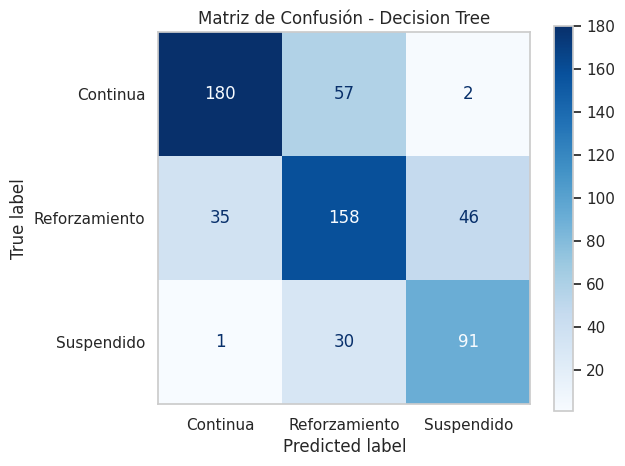

In [37]:
# PROCESO: Entrenamos el primer modelo base. Los árboles de decisión dividen el espacio
# de datos mediante reglas lógicas si/no (ej. si asistencia < 75% -> riesgo).
from sklearn.tree import DecisionTreeClassifier

# Instanciamos el modelo controlando la semilla aleatoria para replicabilidad
modelo_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_dt.fit(X_train_scaled, y_train)

# Predicción y evaluación en el conjunto de prueba
y_pred_dt = modelo_dt.predict(X_test_scaled)
evaluar_clasificador(y_test, y_pred_dt, "Decision Tree")

=== REPORTE DE EVALUACIÓN: Random Forest ===
F1-Score Ponderado (Weighted): 0.7885

                        precision    recall  f1-score   support

   Continua_estudiando       0.90      0.82      0.86       239
Necesita_reforzamiento       0.72      0.76      0.74       239
            Suspendido       0.72      0.77      0.75       122

              accuracy                           0.79       600
             macro avg       0.78      0.78      0.78       600
          weighted avg       0.79      0.79      0.79       600



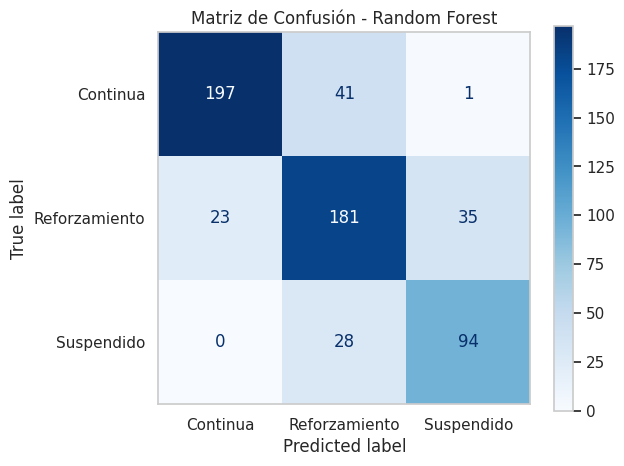

In [38]:
# PROCESO: Entrenamos un modelo de ensamble (Ensemble Learning) de tipo Bagging.
# JUSTIFICACIÓN: Combina múltiples árboles de decisión independientes para reducir la varianza
# y evitar el sobreajuste (overfitting), mejorando la estabilidad de la predicción.
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
modelo_rf.fit(X_train_scaled, y_train)

# Predicción y evaluación
y_pred_rf = modelo_rf.predict(X_test_scaled)
evaluar_clasificador(y_test, y_pred_rf, "Random Forest")

=== REPORTE DE EVALUACIÓN: Support Vector Machine (SVM) ===
F1-Score Ponderado (Weighted): 0.7757

                        precision    recall  f1-score   support

   Continua_estudiando       0.86      0.83      0.85       239
Necesita_reforzamiento       0.70      0.76      0.73       239
            Suspendido       0.78      0.69      0.73       122

              accuracy                           0.78       600
             macro avg       0.78      0.76      0.77       600
          weighted avg       0.78      0.78      0.78       600



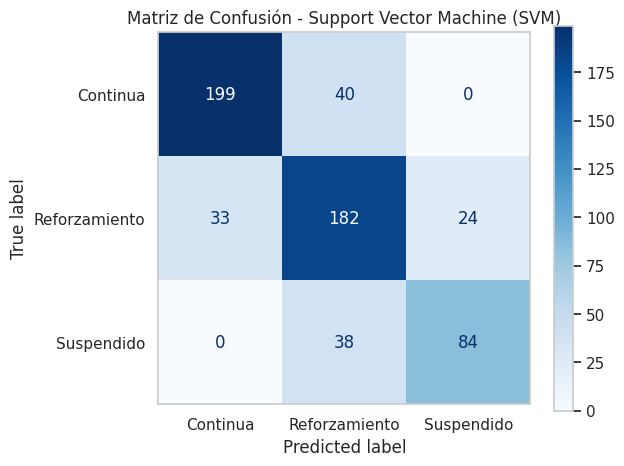

In [39]:
# PROCESO: Entrenamos el tercer algoritmo. SVM busca un hiperplano óptimo en un espacio
# de altas dimensiones que maximice el margen de separación entre las 3 clases.
# JUSTIFICACIÓN: Usamos el kernel 'rbf' (radial) para capturar relaciones no lineales complejas.
from sklearn.svm import SVC

modelo_svm = SVC(kernel='rbf', C=1.0, random_state=42)
modelo_svm.fit(X_train_scaled, y_train)

# Predicción y evaluación
y_pred_svm = modelo_svm.predict(X_test_scaled)
evaluar_clasificador(y_test, y_pred_svm, "Support Vector Machine (SVM)")

=== CUADRO COMPARATIVO FINAL DE MODELOS ===


,Algoritmo/Modelo,F1-Score (Weighted)
0,Random Forest,0.788498
1,Support Vector Machine (SVM),0.775685
2,Decision Tree,0.717022


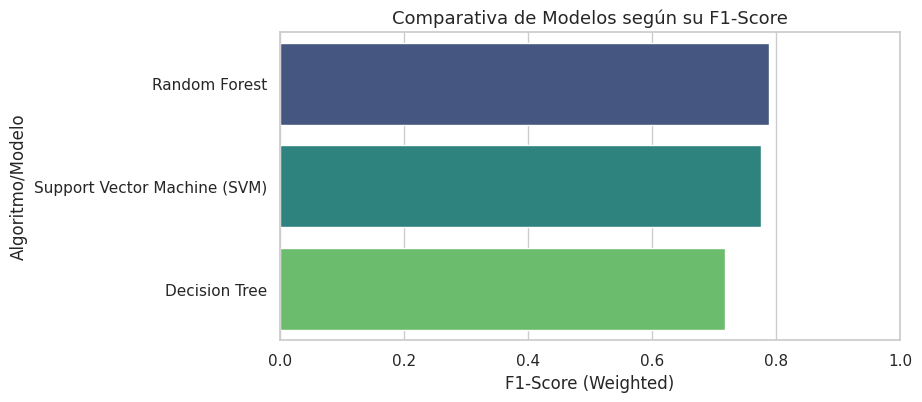

In [40]:
# PROCESO: Creamos un DataFrame consolidado con el F1-Score de los 3 algoritmos.
# JUSTIFICACIÓN: Permite responder directamente al criterio de evaluación "Métricas consideradas con resultados aceptables".
df_comparativa = pd.DataFrame(list(resultados_f1.items()), columns=['Algoritmo/Modelo', 'F1-Score (Weighted)'])
df_comparativa = df_comparativa.sort_values(by='F1-Score (Weighted)', ascending=False).reset_index(drop=True)

print("=== CUADRO COMPARATIVO FINAL DE MODELOS ===")
display(df_comparativa)

# Gráfico de barras comparativo
plt.figure(figsize=(8, 4))
sns.barplot(x='F1-Score (Weighted)', y='Algoritmo/Modelo', data=df_comparativa, palette='viridis', hue='Algoritmo/Modelo', legend=False)
plt.title("Comparativa de Modelos según su F1-Score", fontsize=13)
plt.xlim(0, 1.0)
plt.show()